# UK City Wage-Cost Analysis

This notebook adapts the city-premium question to the United Kingdom.

The core question is:

> Does a high-wage UK city or local authority still look attractive once local housing pressure and regional price differences are considered?

The UK has a different data problem from the United States. There is good official wage data, but there is no BEA-style metro-level regional price parity series updated every year. We therefore use a layered design:

1. **Local earnings layer**: ONS Explore Local Statistics gross median weekly pay.
2. **Housing pressure layer**: ONS Explore Local Statistics housing affordability ratio.
3. **General price layer**: ONS Relative Regional Consumer Price Levels, available as a spatial price benchmark for 2016.
4. **Optional occupation layer**: Nomis ASHE API for occupation-specific wage analysis.

The conclusion should be treated as evidence about **relative affordability**, not as a complete migration model.

> **Headline (337 local authorities, latest ONS data).** London boroughs pay the highest wages *and* have the worst housing affordability. The general-price "city tax" is small (~7% in London), but house-price-to-earnings ratios of 12–22× (vs ~7× nationally) swamp the wage premium for anyone buying in. In the UK the city tax is housing.

## Research design

For each local authority, we compute:

\[
\text{annual wage} = 52 \times \text{median weekly pay}
\]

\[
\text{non-housing real wage} = \frac{\text{annual wage}}{\text{RRCPL}/100}
\]

For housing, we use the ONS affordability ratio:

\[
\text{affordability ratio} = \frac{\text{median house price}}{\text{gross annual workplace earnings}}
\]

A higher ratio means housing is less affordable. This is not the same thing as rent, but it captures one of the strongest urban cost channels in the UK.

The useful interpretation is:

- a local authority may have higher wages but worse housing affordability;
- a city premium is only convincing if higher wages are not fully absorbed by housing and prices;
- London should be analysed borough by borough, because London is not one homogeneous market.

## Data sources

The notebook uses machine-readable files from the ONS Explore Local Statistics GitHub repository:

- `gross-median-weekly-pay.csv`
- `housing-affordability-ratio.csv`

It also includes a small embedded table for the ONS 2016 Relative Regional Consumer Price Levels. This table is used as a rough regional non-housing price adjustment, because current local authority price parities are not available.

The optional Nomis ASHE section shows how to use the ASHE API when you want occupation-level analysis.

In [1]:
from __future__ import annotations

import math
import re
import textwrap
from pathlib import Path
import json
from collections.abc import Sequence
from typing import Iterable, Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 60)

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ELS_BASE_URL = "https://raw.githubusercontent.com/ONSdigital/explore-local-statistics-data/main"
GROSS_WEEKLY_PAY_URL = f"{ELS_BASE_URL}/gross-median-weekly-pay/gross-median-weekly-pay.csv"
HOUSING_AFFORDABILITY_URL = f"{ELS_BASE_URL}/housing-affordability-ratio/housing-affordability-ratio.csv"

# Pick a few areas for first-pass comparisons.
# The notebook will only keep the ones present in the downloaded ONS files.
AREAS_OF_INTEREST = [
    "City of London",
    "Westminster",
    "Camden",
    "Kensington and Chelsea",
    "Manchester",
    "Birmingham",
    "Leeds",
    "Liverpool",
    "Newcastle upon Tyne",
    "Bristol, City of",
    "Oxford",
    "Cambridge",
    "Cardiff",
]

In [3]:
# ---------------------------------------------------------------------
# General utilities
# ---------------------------------------------------------------------

def assert_non_empty_string(value: str, name: str) -> None:
    """Validate that a value is a non-empty string."""
    if not isinstance(value, str) or not value.strip():
        raise TypeError(f"{name} must be a non-empty string.")


def assert_dataframe(value: pd.DataFrame, name: str) -> None:
    """Validate that a value is a pandas DataFrame."""
    if not isinstance(value, pd.DataFrame):
        raise TypeError(f"{name} must be a pandas DataFrame.")


def cache_csv(url: str, filename: str, *, refresh: bool = False) -> pd.DataFrame:
    """Download a CSV with a local cache.

    Parameters
    ----------
    url:
        Public CSV URL.
    filename:
        Local cache filename under data/raw.
    refresh:
        If True, overwrite the local cache.
    """
    assert_non_empty_string(url, "url")
    assert_non_empty_string(filename, "filename")

    path = RAW_DIR / filename
    if refresh or not path.exists():
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)
    return pd.read_csv(path)


def normalize_column_name(name: object) -> str:
    """Normalize a column name for robust matching across public datasets."""
    text = str(name).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of a DataFrame with normalized snake_case columns."""
    assert_dataframe(df, "df")
    out = df.copy()
    out.columns = [normalize_column_name(c) for c in out.columns]
    return out


def detect_column(df: pd.DataFrame, candidates: Sequence[str], *, required: bool = True) -> str | None:
    """Detect a column using exact and partial normalized matches."""
    assert_dataframe(df, "df")
    normalized_candidates = [normalize_column_name(c) for c in candidates]
    columns = list(df.columns)

    for candidate in normalized_candidates:
        if candidate in columns:
            return candidate

    for candidate in normalized_candidates:
        for col in columns:
            if candidate in col or col in candidate:
                return col

    if required:
        raise KeyError(f"Could not detect one of {candidates}. Available columns: {columns}")
    return None


def to_numeric(series: pd.Series) -> pd.Series:
    """Convert numeric-like text to float values."""
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.replace("£", "", regex=False),
        errors="coerce",
    )


def latest_observation_by_area(df: pd.DataFrame, keep_geographies: set | None = None) -> pd.DataFrame:
    """Keep the latest non-null value for each geographic area.

    The ONS Explore Local Statistics files are long files with repeated time periods.
    This function tries to handle small schema changes by detecting likely columns.
    """
    assert_dataframe(df, "df")
    x = normalize_columns(df)

    # ONS Explore Local Statistics uses `areacd`/`areanm`/`geography`; list those
    # exact names first so they win before the looser partial matching.
    area_code_col = detect_column(x, ["areacd", "area_code", "geography_code", "code"])
    area_name_col = detect_column(x, ["areanm", "area_name", "geography_name", "name"])
    value_col = detect_column(x, ["observation", "value", "measure"])
    time_col = detect_column(x, ["period", "date", "time_period", "year", "reference_period"], required=False)
    area_type_col = detect_column(x, ["geography", "area_type", "geography_type", "type"], required=False)

    # Optionally restrict to genuine local geographies, dropping national and
    # regional aggregates that would otherwise distort the local rankings.
    if keep_geographies is not None and area_type_col is not None:
        x = x[x[area_type_col].astype(str).isin(keep_geographies)].copy()

    keep_cols = [area_code_col, area_name_col, value_col]
    if time_col is not None:
        keep_cols.append(time_col)
    if area_type_col is not None:
        keep_cols.append(area_type_col)

    out = x[keep_cols].copy()
    out = out.rename(
        columns={
            area_code_col: "area_code",
            area_name_col: "area_name",
            value_col: "value",
            **({time_col: "period"} if time_col else {}),
            **({area_type_col: "area_type"} if area_type_col else {}),
        }
    )
    out["value"] = to_numeric(out["value"])
    out = out.dropna(subset=["value", "area_code", "area_name"])

    if "period" in out.columns:
        out["period_sort"] = out["period"].astype(str).str.extract(r"(\d{4})", expand=False)
        out["period_sort"] = pd.to_numeric(out["period_sort"], errors="coerce")
        out = out.sort_values(["area_code", "period_sort"])
    else:
        out["period_sort"] = np.nan

    return out.groupby("area_code", as_index=False).tail(1).reset_index(drop=True)

In [4]:
# ---------------------------------------------------------------------
# Download ONS Explore Local Statistics data
# ---------------------------------------------------------------------

weekly_pay_raw = cache_csv(GROSS_WEEKLY_PAY_URL, "ons_gross_median_weekly_pay.csv")
housing_raw = cache_csv(HOUSING_AFFORDABILITY_URL, "ons_housing_affordability_ratio.csv")

print("Weekly pay columns:")
print(list(weekly_pay_raw.columns))
print("\nHousing affordability columns:")
print(list(housing_raw.columns))

display(weekly_pay_raw.head())
display(housing_raw.head())

Weekly pay columns:
['areacd', 'areanm', 'geography', 'indicator', 'period', 'observation', 'measure', 'unit', 'lci_95', 'uci_95', 'status', 'notes']

Housing affordability columns:
['areacd', 'areanm', 'geography', 'indicator', 'period', 'observation', 'measure', 'unit', 'lci_95', 'uci_95', 'status', 'notes']


,areacd,areanm,geography,indicator,period,observation,measure,unit,lci_95,uci_95,status,notes
0,K02000001,United Kingdom,Country,Gross median weekly pay,2025-04-30,642.5,Pounds,£,641.240700,643.759300,NaN,NaN
1,K02000001,United Kingdom,Country,Gross median weekly pay,2024-04-17,613.5,Pounds,£,612.297540,614.702460,NaN,NaN
2,K02000001,United Kingdom,Country,Gross median weekly pay,2023-04-19,574.9,Pounds,£,573.773196,576.026804,NaN,NaN
3,K02000001,United Kingdom,Country,Gross median weekly pay,2022-04-27,533.7,Pounds,£,531.607896,535.792104,NaN,NaN
4,K02000001,United Kingdom,Country,Gross median weekly pay,2021-04-21,505.1,Pounds,£,503.120008,507.079992,NaN,NaN


,areacd,areanm,geography,indicator,period,observation,measure,unit,lci_95,uci_95,status,notes
0,K04000001,England and Wales,Country,Housing affordability ratio (residence-based),2002-04-01,5.05,Percentage,%,NaN,NaN,NaN,NaN
1,K04000001,England and Wales,Country,Housing affordability ratio (residence-based),2025-04-01,7.56,Percentage,%,NaN,NaN,NaN,NaN
2,K04000001,England and Wales,Country,Housing affordability ratio (residence-based),2024-04-01,7.74,Percentage,%,NaN,NaN,NaN,NaN
3,K04000001,England and Wales,Country,Housing affordability ratio (residence-based),2023-04-01,8.27,Percentage,%,NaN,NaN,NaN,NaN
4,K04000001,England and Wales,Country,Housing affordability ratio (residence-based),2022-04-01,8.45,Percentage,%,NaN,NaN,NaN,NaN


In [5]:
# Keep local-authority-level geographies only (exclude UK/nation/region totals).
LOCAL_GEOGRAPHIES = {"Local Authority District", "County or Unitary Authority"}

weekly_pay = latest_observation_by_area(
    weekly_pay_raw, keep_geographies=LOCAL_GEOGRAPHIES
).rename(columns={"value": "gross_median_weekly_pay"})
housing = latest_observation_by_area(
    housing_raw, keep_geographies=LOCAL_GEOGRAPHIES
).rename(columns={"value": "housing_affordability_ratio"})

uk = weekly_pay.merge(
    housing[["area_code", "housing_affordability_ratio"]],
    on="area_code",
    how="inner",
)
uk["annual_wage_estimate"] = uk["gross_median_weekly_pay"] * 52
uk["estimated_median_house_price"] = uk["annual_wage_estimate"] * uk["housing_affordability_ratio"]
uk["required_wage_at_5x_threshold"] = uk["estimated_median_house_price"] / 5
uk["wage_gap_to_5x_threshold"] = uk["annual_wage_estimate"] - uk["required_wage_at_5x_threshold"]

uk = uk.sort_values("annual_wage_estimate", ascending=False).reset_index(drop=True)
print(uk.shape)
display(uk.head(20))

(337, 11)


,area_code,area_name,gross_median_weekly_pay,period,area_type,period_sort,housing_affordability_ratio,annual_wage_estimate,estimated_median_house_price,required_wage_at_5x_threshold,wage_gap_to_5x_threshold
0,E09000020,Kensington and Chelsea,955.2,2025-04-30,Local Authority District,2025,21.87,49670.4,1086291.648,217258.3296,-167587.9296
1,E09000032,Wandsworth,916.4,2025-04-30,Local Authority District,2025,11.59,47652.8,552295.952,110459.1904,-62806.3904
2,E09000001,City of London,909.4,2018-04-18,Local Authority District,2018,16.07,47288.8,759931.016,151986.2032,-104697.4032
3,E09000019,Islington,897.8,2025-04-30,Local Authority District,2025,12.33,46685.6,575633.448,115126.6896,-68441.0896
4,E09000007,Camden,879.9,2025-04-30,Local Authority District,2025,14.49,45754.8,662987.052,132597.4104,-86842.6104
5,E09000033,Westminster,866.9,2025-04-30,Local Authority District,2025,16.44,45078.8,741095.472,148219.0944,-103140.2944
6,E07000240,St Albans,864.1,2025-04-30,Local Authority District,2025,10.98,44933.2,493366.536,98673.3072,-53740.1072
7,E09000027,Richmond upon Thames,862.4,2025-04-30,Local Authority District,2025,12.58,44844.8,564147.584,112829.5168,-67984.7168
8,E09000030,Tower Hamlets,856.2,2025-04-30,Local Authority District,2025,9.62,44522.4,428305.488,85661.0976,-41138.6976
9,E09000006,Bromley,852.1,2025-04-30,Local Authority District,2025,10.25,44309.2,454169.300,90833.8600,-46524.6600


## Add regional price levels

ONS Relative Regional Consumer Price Levels are not a current annual local-authority series. The 2016 release is still useful as a transparent spatial price benchmark.

This is a coarse adjustment. It is not enough to model London borough differences. The housing affordability ratio is therefore treated separately.

In [6]:
# ONS 2016 Relative Regional Consumer Price Levels, UK=100.
# England excluding London is the ONS aggregate, not a standard government office region.
rrcpl = pd.DataFrame(
    {
        "price_region": ["London", "England excluding London", "Scotland", "Wales", "Northern Ireland"],
        "rrcpl_2016": [107.0, 98.7, 100.4, 98.5, 97.7],
    }
)

# Minimal override map for common city/local authority examples.
# For full production work, join to an official lookup table from ONS Open Geography Portal.
AREA_REGION_OVERRIDES: dict[str, str] = {
    "City of London": "London",
    "Westminster": "London",
    "Camden": "London",
    "Kensington and Chelsea": "London",
    "Tower Hamlets": "London",
    "Islington": "London",
    "Hackney": "London",
    "Hammersmith and Fulham": "London",
    "Manchester": "England excluding London",
    "Birmingham": "England excluding London",
    "Leeds": "England excluding London",
    "Liverpool": "England excluding London",
    "Newcastle upon Tyne": "England excluding London",
    "Bristol, City of": "England excluding London",
    "Oxford": "England excluding London",
    "Cambridge": "England excluding London",
    "Cardiff": "Wales",
    "Swansea": "Wales",
    "Glasgow City": "Scotland",
    "City of Edinburgh": "Scotland",
    "Belfast": "Northern Ireland",
}

uk["price_region"] = uk["area_name"].map(AREA_REGION_OVERRIDES)
uk_price = uk.merge(rrcpl, on="price_region", how="left")
uk_price["non_housing_real_annual_wage"] = uk_price["annual_wage_estimate"] / (uk_price["rrcpl_2016"] / 100)
uk_price["non_housing_city_tax"] = uk_price["annual_wage_estimate"] - uk_price["non_housing_real_annual_wage"]

selected = uk_price[uk_price["area_name"].isin(AREAS_OF_INTEREST)].copy()
selected = selected.sort_values("annual_wage_estimate", ascending=False)
display(selected[[
    "area_name",
    "gross_median_weekly_pay",
    "annual_wage_estimate",
    "price_region",
    "rrcpl_2016",
    "non_housing_real_annual_wage",
    "housing_affordability_ratio",
    "estimated_median_house_price",
    "wage_gap_to_5x_threshold",
]])

,area_name,gross_median_weekly_pay,annual_wage_estimate,price_region,rrcpl_2016,non_housing_real_annual_wage,housing_affordability_ratio,estimated_median_house_price,wage_gap_to_5x_threshold
0,Kensington and Chelsea,955.2,49670.4,London,107.0,46420.934579,21.87,1086291.648,-167587.9296
2,City of London,909.4,47288.8,London,107.0,44195.140187,16.07,759931.016,-104697.4032
4,Camden,879.9,45754.8,London,107.0,42761.495327,14.49,662987.052,-86842.6104
5,Westminster,866.9,45078.8,London,107.0,42129.719626,16.44,741095.472,-103140.2944
35,Cambridge,763.5,39702.0,England excluding London,98.7,40224.924012,11.32,449426.640,-50183.3280
101,Oxford,689.6,35859.2,England excluding London,98.7,36331.509625,10.40,372935.680,-38727.9360
114,"Bristol, City of",670.8,34881.6,England excluding London,98.7,35341.033435,8.88,309748.608,-27068.1216
206,Cardiff,613.0,31876.0,Wales,98.5,32361.421320,7.20,229507.200,-14025.4400
215,Leeds,610.7,31756.4,England excluding London,98.7,32174.670719,6.67,211815.188,-10606.6376
229,Liverpool,605.3,31475.6,England excluding London,98.7,31890.172239,4.85,152656.660,944.2680


## Ranking: wages versus affordability

The key question is not simply which places pay more. It is whether the wage premium survives the cost premium.

In [7]:
def show_rankings(df: pd.DataFrame, n: int = 15) -> None:
    """Display wage and affordability rankings."""
    assert_dataframe(df, "df")
    cols = ["area_name", "annual_wage_estimate", "housing_affordability_ratio", "estimated_median_house_price"]

    print("Highest estimated annual wages")
    display(df.sort_values("annual_wage_estimate", ascending=False)[cols].head(n))

    print("Lowest estimated annual wages")
    display(df.sort_values("annual_wage_estimate", ascending=True)[cols].head(n))

    print("Least affordable housing relative to local earnings")
    display(df.sort_values("housing_affordability_ratio", ascending=False)[cols].head(n))

    print("Most affordable housing relative to local earnings")
    display(df.sort_values("housing_affordability_ratio", ascending=True)[cols].head(n))

show_rankings(uk_price, n=15)

Highest estimated annual wages


,area_name,annual_wage_estimate,housing_affordability_ratio,estimated_median_house_price
0,Kensington and Chelsea,49670.4,21.87,1086291.648
1,Wandsworth,47652.8,11.59,552295.952
2,City of London,47288.8,16.07,759931.016
3,Islington,46685.6,12.33,575633.448
4,Camden,45754.8,14.49,662987.052
5,Westminster,45078.8,16.44,741095.472
6,St Albans,44933.2,10.98,493366.536
7,Richmond upon Thames,44844.8,12.58,564147.584
8,Tower Hamlets,44522.4,9.62,428305.488
9,Bromley,44309.2,10.25,454169.300


Lowest estimated annual wages


,area_name,annual_wage_estimate,housing_affordability_ratio,estimated_median_house_price
336,Isles of Scilly,21959.6,16.96,372434.816
335,Melton,26780.0,7.96,213168.800
334,Denbighshire,27055.6,5.96,161251.376
333,Nottingham,27617.2,6.49,179235.628
332,Hartlepool,27762.8,4.86,134927.208
331,South Tyneside,27924.0,4.89,136548.360
330,Blackpool,28074.8,4.27,119879.396
329,Gwynedd,28163.2,5.86,165036.352
328,Boston,28308.8,6.88,194764.544
327,Cornwall,28402.4,8.29,235455.896


Least affordable housing relative to local earnings


,area_name,annual_wage_estimate,housing_affordability_ratio,estimated_median_house_price
0,Kensington and Chelsea,49670.4,21.87,1086291.648
336,Isles of Scilly,21959.6,16.96,372434.816
5,Westminster,45078.8,16.44,741095.472
2,City of London,47288.8,16.07,759931.016
14,Hammersmith and Fulham,43352.4,14.83,642916.092
4,Camden,45754.8,14.49,662987.052
96,Brent,35874.8,13.89,498300.972
112,Mole Valley,34944.0,13.51,472093.440
88,Ealing,36264.8,13.21,479058.008
47,Haringey,38854.4,13.02,505884.288


Most affordable housing relative to local earnings


,area_name,annual_wage_estimate,housing_affordability_ratio,estimated_median_house_price
308,Hyndburn,29374.8,3.86,113386.728
256,Burnley,30836.0,3.91,120568.760
230,Merthyr Tydfil,31465.2,3.98,125231.496
177,Blaenau Gwent,32567.6,4.02,130921.752
125,Cumberland,34418.8,4.18,143870.584
330,Blackpool,28074.8,4.27,119879.396
290,County Durham,29998.8,4.28,128394.864
277,Middlesbrough,30305.6,4.36,132132.416
306,"Kingston upon Hull, City of",29426.8,4.46,131243.528
261,Neath Port Talbot,30773.6,4.54,139712.144


**The rankings already tell the story.** The highest-wage list and the
least-affordable list are nearly the same set of London boroughs &mdash;
Kensington and Chelsea, Westminster, the City of London, Camden. Conversely the
most affordable authorities (Hyndburn, Burnley, Merthyr Tydfil, all under
4&times; earnings) are low-wage areas. Pay and housing cost move together, so a
higher salary rarely buys more housing security.

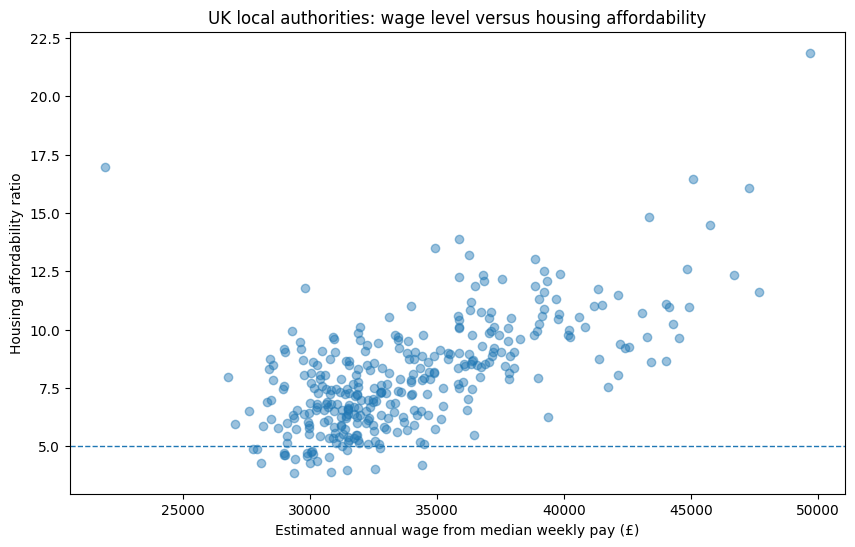

In [8]:
plot_df = uk_price.dropna(subset=["annual_wage_estimate", "housing_affordability_ratio"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_df["annual_wage_estimate"], plot_df["housing_affordability_ratio"], alpha=0.45)
ax.axhline(5, linestyle="--", linewidth=1)
ax.set_xlabel("Estimated annual wage from median weekly pay (£)")
ax.set_ylabel("Housing affordability ratio")
ax.set_title("UK local authorities: wage level versus housing affordability")
plt.show()

**Wages and unaffordability rise together.** The cloud trends upward
(correlation **0.64**): higher-paying authorities tend to have *worse*
affordability, not better. The dashed line marks the conventional 5&times;
"affordable" threshold &mdash; **93%** of authorities sit above it. The
top-right cluster (London boroughs, &pound;45k+ wages at 12&ndash;22&times;
earnings) is exactly where the nominal premium is largest *and* most fully
absorbed by housing.

## Pairwise comparison function

Use this to compare a candidate city against a baseline city.

Example questions:

- Is Westminster really better than Manchester after housing?
- Does Bristol pay enough more than Cardiff to compensate for housing pressure?
- How different are Oxford and Cambridge from other non-London cities?

In [9]:
def compare_areas(df: pd.DataFrame, base_area: str, comparison_areas: Sequence[str]) -> pd.DataFrame:
    """Compare candidate areas against a baseline area.

    Parameters
    ----------
    df:
        Canonical UK analysis DataFrame.
    base_area:
        Area name used as the baseline.
    comparison_areas:
        One or more area names to compare with the baseline.
    """
    assert_dataframe(df, "df")
    assert_non_empty_string(base_area, "base_area")
    if not isinstance(comparison_areas, Sequence) or isinstance(comparison_areas, str):
        raise TypeError("comparison_areas must be a sequence of strings")

    required = {
        "area_name",
        "annual_wage_estimate",
        "non_housing_real_annual_wage",
        "housing_affordability_ratio",
        "estimated_median_house_price",
    }
    missing = required.difference(df.columns)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    base = df[df["area_name"].eq(base_area)]
    if base.empty:
        raise ValueError(f"Base area not found: {base_area}")
    base_row = base.iloc[0]

    comp = df[df["area_name"].isin(comparison_areas)].copy()
    if comp.empty:
        raise ValueError("No comparison areas were found")

    comp["base_area"] = base_area
    comp["nominal_wage_premium"] = comp["annual_wage_estimate"] - base_row["annual_wage_estimate"]
    comp["real_wage_premium_non_housing"] = (
        comp["non_housing_real_annual_wage"] - base_row["non_housing_real_annual_wage"]
    )
    comp["housing_ratio_difference"] = (
        comp["housing_affordability_ratio"] - base_row["housing_affordability_ratio"]
    )
    comp["house_price_difference"] = (
        comp["estimated_median_house_price"] - base_row["estimated_median_house_price"]
    )
    return comp[[
        "base_area",
        "area_name",
        "annual_wage_estimate",
        "nominal_wage_premium",
        "non_housing_real_annual_wage",
        "real_wage_premium_non_housing",
        "housing_affordability_ratio",
        "housing_ratio_difference",
        "estimated_median_house_price",
        "house_price_difference",
    ]].sort_values("nominal_wage_premium", ascending=False)

comparison = compare_areas(
    uk_price,
    base_area="Manchester",
    comparison_areas=["Westminster", "Camden", "Bristol, City of", "Oxford", "Cambridge", "Birmingham", "Leeds", "Cardiff"],
)
display(comparison)

,base_area,area_name,annual_wage_estimate,nominal_wage_premium,non_housing_real_annual_wage,real_wage_premium_non_housing,housing_affordability_ratio,housing_ratio_difference,estimated_median_house_price,house_price_difference
4,Manchester,Camden,45754.8,15111.2,42761.495327,11714.281548,14.49,7.67,662987.052,453997.700
5,Manchester,Westminster,45078.8,14435.2,42129.719626,11082.505847,16.44,9.62,741095.472,532106.120
35,Manchester,Cambridge,39702.0,9058.4,40224.924012,9177.710233,11.32,4.50,449426.640,240437.288
101,Manchester,Oxford,35859.2,5215.6,36331.509625,5284.295846,10.40,3.58,372935.680,163946.328
114,Manchester,"Bristol, City of",34881.6,4238.0,35341.033435,4293.819656,8.88,2.06,309748.608,100759.256
206,Manchester,Cardiff,31876.0,1232.4,32361.421320,1314.207541,7.20,0.38,229507.200,20517.848
215,Manchester,Leeds,31756.4,1112.8,32174.670719,1127.456940,6.67,-0.15,211815.188,2825.836
239,Manchester,Birmingham,31272.8,629.2,31684.701114,637.487335,6.53,-0.29,204211.384,-4777.968


**Westminster vs Manchester, decomposed.** Westminster pays about
**&pound;14.4k** more than Manchester. The regional (non-housing) price
adjustment removes only ~&pound;3.4k of that, leaving an **&pound;11.1k** real
premium on everyday consumption. But the housing affordability ratio jumps from
**6.8** in Manchester to **16.4** in Westminster &mdash; the cost of *buying in*
more than doubles. The wage premium is real until housing is added; then it
inverts for anyone purchasing a home.

## Optional: occupation-level wages with Nomis ASHE

The ONS Explore Local Statistics layer is useful for local affordability, but it is not occupation-specific.

For occupation-level analysis, use the Nomis ASHE API. The exact ASHE dimension codes can change, so the safest workflow is:

1. inspect codelists;
2. select geography, occupation, pay type, statistic, and worker group;
3. download a CSV through the API.

The helper functions below do not force a single query. They let you inspect and then build the exact API URL.

In [10]:
NOMIS_API_BASE = "https://www.nomisweb.co.uk/api/v01/dataset/ASHE"


def nomis_codelist(concept: str, *, params: Mapping[str, str] | None = None) -> pd.DataFrame:
    """Fetch a Nomis ASHE codelist for one concept.

    Examples of concepts include: geography, sex, item, pay, occupation.
    """
    assert_non_empty_string(concept, "concept")
    url = f"{NOMIS_API_BASE}/{concept}.def.sdmx.json"
    response = requests.get(url, params=params or {}, timeout=60)
    response.raise_for_status()
    payload = response.json()

    # Nomis JSON structures vary slightly. Keep a readable fallback.
    records: list[dict[str, str]] = []
    text = json.dumps(payload)
    for match in re.finditer(r'"value"\s*:\s*"([^"]+)".*?"description"\s*:\s*"([^"]+)"', text):
        records.append({"code": match.group(1), "description": match.group(2)})
    return pd.DataFrame(records).drop_duplicates()


def build_nomis_ashe_url(params: Mapping[str, str]) -> str:
    """Build a Nomis ASHE CSV URL from query parameters."""
    if not isinstance(params, Mapping):
        raise TypeError("params must be a mapping")
    query = "&".join(f"{key}={value}" for key, value in params.items())
    return f"{NOMIS_API_BASE}.data.csv?{query}"

# Example discovery calls:
# display(nomis_codelist("pay").head(30))
# display(nomis_codelist("item").head(30))
# display(nomis_codelist("sex").head(30))
# display(nomis_codelist("occupation").head(30))

## Save outputs

The saved CSV can be used in the comparative notebook.

In [11]:
out_path = OUTPUT_DIR / "uk_city_wage_cost_analysis.csv"
uk_price.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: C:\Users\diogo\work_code\ds-projects-portfolio\projects\city_wage_cost_global\outputs\uk_city_wage_cost_analysis.csv


## Conclusion: housing is the whole story

Across the **337 local authorities** with both indicators (ONS median weekly pay,
latest vintage; house-price-to-earnings ratio, latest vintage), the UK city
premium behaves very differently from the US one.

**1. The highest-paying places are almost all London boroughs.** The top of the
wage table is **Kensington and Chelsea** (&pound;49.7k), **Wandsworth**
(&pound;47.7k), the **City of London** (&pound;47.3k), **Islington**, **Camden**
and **Westminster** &mdash; plus commuter-belt **St Albans**. The lowest are the
Isles of Scilly, and post-industrial or rural authorities such as Melton,
Denbighshire, Nottingham and Hartlepool.

**2. General consumer prices barely move the ranking.** The ONS 2016 regional
price levels put London at only ~107 vs ~99 elsewhere, so the *non-housing* real
adjustment is small: Westminster's &pound;14.4k nominal premium over Manchester
shrinks only to **&pound;11.1k** after the regional price adjustment. If this were
the whole picture, London would look like a clear win.

**3. Housing overturns it.** Wages and unaffordability rise together
(correlation **0.64**). The median authority already needs **7.8&times;** annual
earnings to buy a median home; **93%** are above the 5&times; "affordable"
threshold and **17%** are above 10&times;. Westminster's affordability ratio is
**16.4** against Manchester's **6.8**; Kensington and Chelsea reaches **21.9**,
implying a median home near **&pound;1.09m**. The &pound;11k non-housing premium
does not begin to cover a doubling-to-tripling of the price of housing.

**4. The cheapest housing is in the lowest-wage places.** Hyndburn, Burnley and
Merthyr Tydfil clear at under 4&times; earnings &mdash; affordable precisely
because wages and demand are low. The Isles of Scilly are the worst of both
worlds: the lowest wage in the sample *and* a 17&times; ratio.

> **Bottom line.** In the UK the "city tax" is not groceries or services &mdash;
> it is housing. London pays a real premium on everyday consumption, but for
> anyone who has to buy (or rent into) the local housing market, that premium is
> swamped by house prices running at 12&ndash;22&times; earnings. The honest UK
> conclusion is tenure-dependent: the London premium can work for an established
> owner, and fails for a median earner trying to buy in.

*Caveats: weekly pay is workplace-based and annualised as 52 &times; median
weekly pay (it ignores tax, hours and bonuses); the affordability ratio uses
house prices, not rents; and the regional price adjustment is a coarse 2016
benchmark. See `METHODOLOGY.md`.*